In [ ]:
import os
from graphviz import Digraph
from IPython.display import Image, display


class Mini_Path:
    class Node:
        def __init__(self, val):
            self.d = float("inf")
            self.par = None

    def __init__(self, n, E, s):
        self.V = [self.Node(i) for i in range(n)]
        self.E = E

        self.s = s
        self.V[s].d = 0

    def relax(self, u, v):
        nu, nv = self.V[u], self.V[v]
        if nv.d > nu.d + self.E[(u, v)]:
            nv.d = nu.d + self.E[(u, v)]
            nv.par = nu
            return True
        return False

    def bellman_ford(self):
        for _ in range(len(self.V) - 1):
            self.draw()
            has_relax = False
            for u, v in self.E.keys():
                has_relax |= self.relax(u, v)
            # 如果没发生更新, 则提前结束
            if not has_relax:
                break

        neg = []
        for u, v in self.E.keys():
            nu, nv = self.V[u], self.V[v]
            # 如果还能松弛, 说明存在负环
            if nv.d > nu.d + self.E[(u, v)]:
                neg.append(v)

        # 如果没有负环, 则直接返回
        if len(neg) == 0:
            return

        # 构建邻接表 用于进行广搜
        adj = [[] for _ in range(len(self.V))]
        for u, v in self.E.keys():
            adj[u].append(v)

        # 传播负无穷距离
        while len(neg) > 0:
            u = neg.pop()
            self.V[u].d = -float("inf")
            for v in adj[u]:
                if self.V[v].d != -float("inf"):
                    neg.append(v)

    def draw(self):
        int_chr = {0: "s", 1: "t", 2: "x", 3: "y", 4: "z"}

        dot = Digraph()
        dot.attr(rankdir="LR")
        dot.attr("node", shape="circle", fontsize="30")
        dot.attr("edge", fontsize="35")
        for i in range(len(self.V)):
            dot.node(str(i), f"{int_chr[i]}\n{self.V[i].d}")
        for u, v in self.E.keys():
            if self.V[v].par == self.V[u]:
                dot.edge(str(u), str(v), label=str(self.E[(u, v)]), color="dodgerblue", penwidth="6")
            else:
                dot.edge(str(u), str(v), label=str(self.E[(u, v)]))
        dot.render("demo", format="png", cleanup=True)
        display(Image("demo.png"))
        os.remove("demo.png")

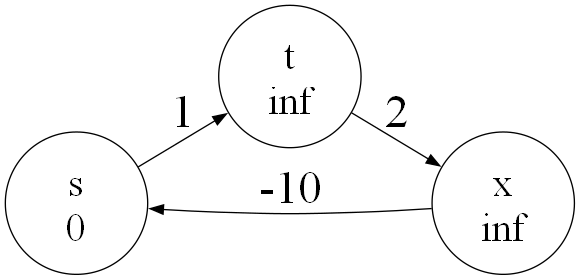

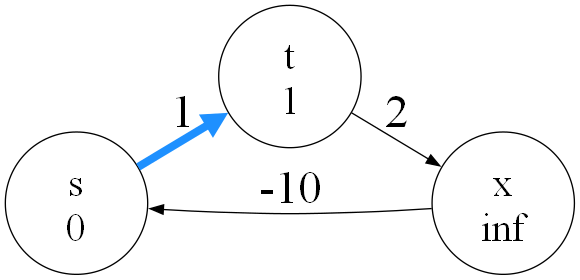

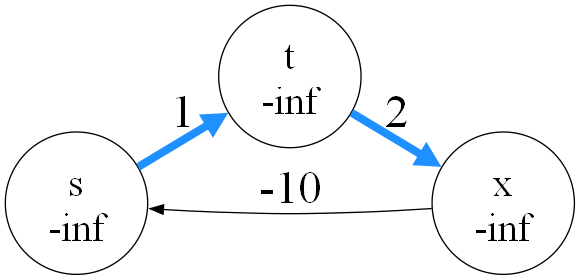

In [ ]:
E = {(2, 0): -10, (1, 2): 2, (0, 1): 1}
G = Mini_Path(3, E, 0)
G.bellman_ford()
G.draw()

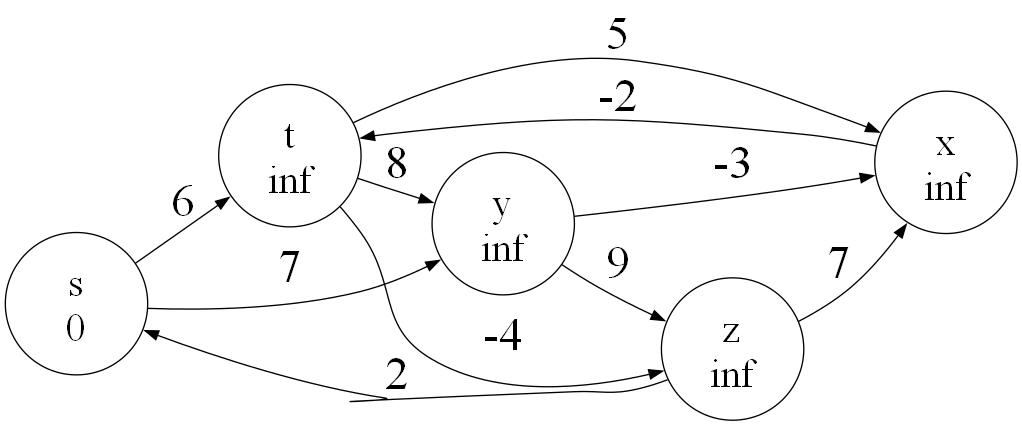

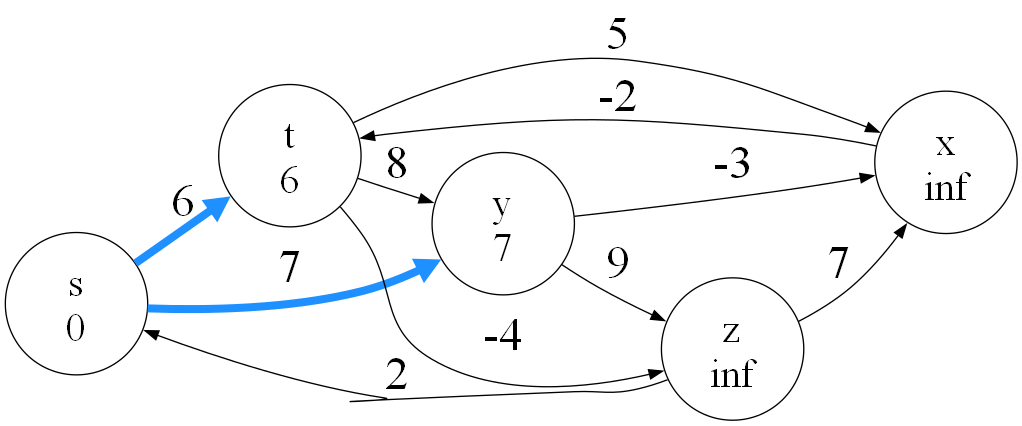

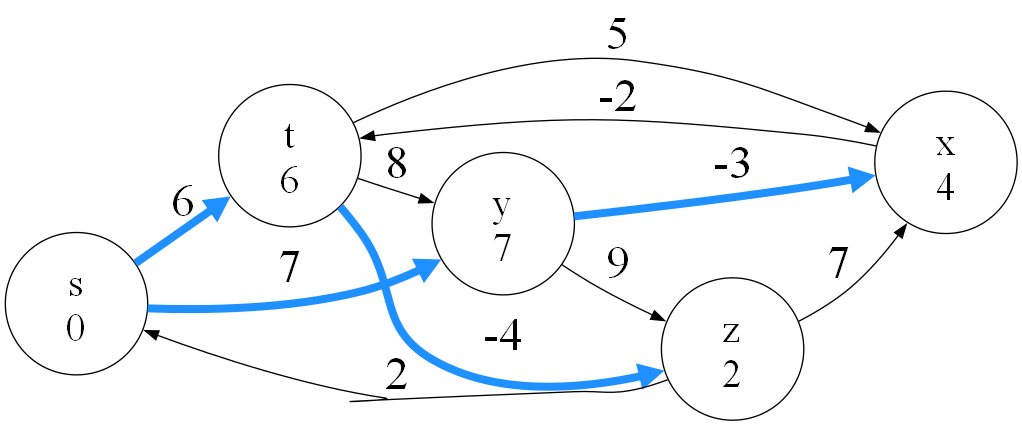

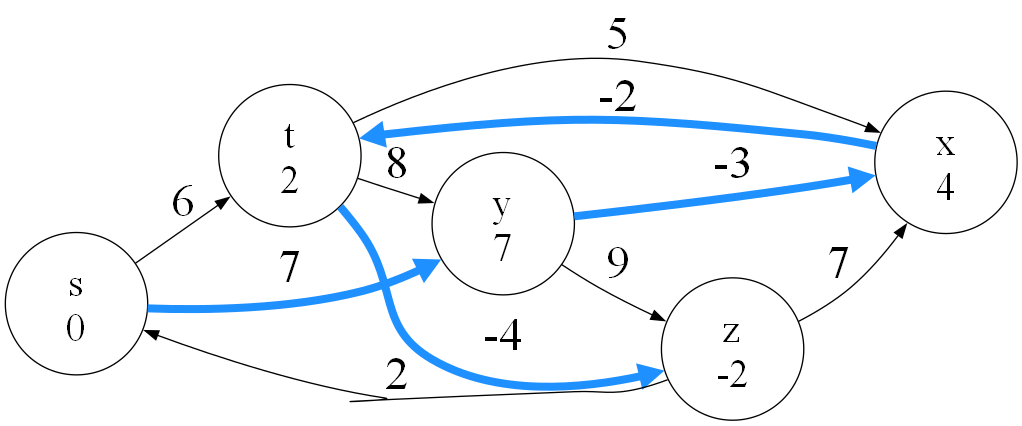

In [36]:
int_chr = {0: "s", 1: "t", 2: "x", 3: "y", 4: "z"}
chr_int = {v: k for k, v in int_chr.items()}
E = {("x", "t"): -2, ("z", "s"): 2, ("z", "x"): 7, ("y", "x"): -3, ("y", "z"): 9, ("t", "x"): 5, ("t", "y"): 8, ("t", "z"): -4, ("s", "t"): 6, ("s", "y"): 7}
E = {(chr_int[u], chr_int[v]): w for (u, v), w in E.items()}

G = Mini_Path(5, E, chr_int["s"])
G.bellman_ford()